##### `Mohanna Miri`
# Decision Tree From scratch with Python

1. Node Structure
2. DecisionTreeFromScratch Class (Gini/Entropy impurity criterion, fit, _best_split, and predict)
3. Training the Model on a Sample Dataset (Two Moons)
4. Model Accuracy Evaluation
5. Plotting the Decision Boundary
6. Bonus: Investigating the Effect of max_depth on Overfitting

## 1. Libraries


In [52]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Optional, Tuple, List

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

## 2. Node structure
Each node is either an internal node (which splits the data based on a feature and a threshold)
or a leaf node (which stores the final prediction value).

In [53]:
@dataclass
class Node:

    """A node in the decision tree.

    Attributes:
        - feature_index: The column index of the feature used for splitting
            (only for internal nodes).
        - threshold: The threshold value used for splitting
            (only for internal nodes).
        - left: The left subtree (samples where feature <= threshold).
        - right: The right subtree (samples where feature > threshold).
        - value: The predicted label (only for leaf nodes; otherwise None).
        - gini: The impurity value of this node (for analysis/debugging only).
        - n_samples: The number of samples that reach this node.
    """

    feature_index: Optional[int] = None
    threshold: Optional[float] = None
    left: Optional["Node"] = None
    right: Optional["Node"] = None
    value: Optional[int] = None
    gini: Optional[float] = None
    n_samples: int = 0

    def is_leaf(self) -> bool:
        """Check whether this node is a leaf node."""
        return self.value is not None

## 3. The main Decision Tree class
### 3.1 constructor (`__init__`) and Impurity Criteria(`Gini/Entropy`)

In [54]:
class DecisionTreeFromScratch:
    """Decision tree implementation for classification without using scikit-learn.

Args:
    max_depth: The maximum allowed depth of the tree. If None, the tree
        grows as long as further splitting is possible (which may increase
        the risk of overfitting).
    min_samples_split: The minimum number of samples required in a node
        for that node to be split.
    criterion: The impurity criterion; one of {"gini", "entropy"}.
"""
    def __init__(
        self,
        max_depth: Optional[int] = None,
        min_samples_split: int = 2,
        criterion: str = "gini", ) -> None:

        if criterion not in ("gini", "entropy"):
            raise ValueError("criterion should be 'gini' or 'entropy'." )

        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.criterion = criterion 
        self.root : Optional[Node] = None
        self.n_classes_ : int=0
        self.n_features_ : int=0


    @staticmethod
    def _gini(y: np.ndarray) -> float:
        """Compute the Gini impurity for the label vector y.

        Gini = 1 - sum(p_i ^ 2), where p_i is the proportion of samples
        belonging to class i.

        The smaller the value, the purer the node is.
        """
        m=len(y)
        if m==0:
            return 0.0

        _ , counts= np.unique(y, return_counts=True)
        probabilities = counts / m
        return 1.0 - np.sum( probabilities ** 2 )

    @staticmethod
    def _entropy(y: np.ndarray) -> float:
        """Compute the entropy for the label vector y.

        Entropy = -sum(p_i * log2(p_i))
        """
        m=len(y)
        if m==0 :
            return 0.0
        _,counts = np.unique(y, return_counts=True)
        probabilities = counts / m 
        probabilities = probabilities[probabilities > 0] #remove the zeros 
        return -np.sum(probabilities * np.log2(probabilities))

    def _impurity(self, y:np.ndarray) -> float:
        """Select the impurity criterion based on the class settings (gini or entropy)."""
        if self.criterion == "gini":
            return self._gini(y)
        return self._entropy(y)


print("The DecisionTreeFromScratch class (initial version) has been defined.")

The DecisionTreeFromScratch class (initial version) has been defined.


### 3.2  Finding the Best Split (`_best_split`)

For each feature, all unique values are considered as candidate thresholds, and the split that produces the greatest reduction in impurity (Impurity Gain) is selected. This method is added to the class above using monkey patching.


In [55]:
def _best_split(
    self, X: np.ndarray, y:np.ndarray) -> Tuple[Optional[int], Optional[float], float]:
    """Finds the best feature and threshold for splitting the data at the current node.

    Args:
    X: The feature matrix with shape (n_samples, n_features).
    y: The label vector with shape (n_samples,).

    Returns:
    A tuple containing (best feature index, best threshold, highest impurity reduction).
    If no valid split is found, (None, None, 0.0) is returned.
    """
    n_samples, n_features = X.shape
    if n_samples < self.min_samples_split:
        return None, None, 0.0

    parent_impurity = self._impurity(y)
    best_gain = 0.0
    best_feature_index : Optional[int] = None
    best_threshold : Optional[float] = None

    for feature_index in range(n_features):
        column = X[:, feature_index]
        thresholds = np.unique(column)

        for threshold in thresholds:
            left_mask = column <= threshold
            right_mask = ~left_mask

            n_left = np.sum(left_mask)
            n_right = np.sum(right_mask)
            if n_left==0 or n_right==0:
                continue

            y_left , y_right = y[left_mask] , y[right_mask]
            impurity_left = self._impurity(y_left)
            impurity_right = self._impurity(y_right)

            weighted_impurity = (
                n_left / n_samples * impurity_left
              + n_right / n_samples * impurity_right
            )
            gain = parent_impurity - weighted_impurity

            if gain > best_gain:
                best_gain = gain
                best_feature_index = feature_index
                best_threshold = threshold

    return best_feature_index , best_threshold , best_gain

DecisionTreeFromScratch._best_split = _best_split
print("_best_split method has been added.")            

_best_split method has been added.


### 3.3 Recursive Tree Construction(`fit` / `_grow_tree`)

In [56]:
def _most_common_label(self, y: np.ndarray) -> int:
    """Returns the most frequent label in y (for leaf nodes)."""
    values , counts = np.unique(y, return_counts=True)
    return int(values[np.argmax(counts)])

def _grow_tree(self, X: np.ndarray, y: np.ndarray, depth: int = 0) -> Node :
    """Recursively builds the subtree corresponding to the data (X, y).

        This method checks the stopping criteria: maximum depth, minimum number of samples required for splitting, and complete purity of the node (Gini/Entropy = 0).
        If none of these conditions is met, it finds the best split and recursively builds the left and right subtrees.

        Args:
        X: Matrix of samples that have reached this node.
        y: Vector of labels corresponding to those samples.
        depth: The current depth of the node in the tree (the root has depth 0).

        Returns:
        The constructed node (Node), which can be either a leaf node or an internal node.
        """
    n_samples = len(y)
    node_impurity = self._impurity(y)

    is_pure = node_impurity==0
    reached_max_depth = self.max_depth is not None and depth >= self.max_depth
    too_few_samples = n_samples < self.min_samples_split

    if is_pure or reached_max_depth or too_few_samples :
        return Node(
            value =self._most_common_label(y),
            gini = node_impurity,
            n_samples = n_samples,
        )
    feature_index, threshold, gain = self._best_split(X,y)

    if feature_index is None or gain <= 0.0:
        return Node(
            value =self._most_common_label(y),
            gini = node_impurity,
            n_samples = n_samples,
        )
    
    left_mask = X[:, feature_index] <= threshold
    right_mask = ~left_mask

    left_child = self._grow_tree(X[left_mask], y[left_mask], depth + 1)
    right_child = self._grow_tree(X[right_mask], y[right_mask], depth + 1)

    return Node(
        feature_index=feature_index,
        threshold=threshold,
        left=left_child,
        right=right_child,
        gini=node_impurity,
        n_samples=n_samples,
    )

def fit(self, X:np.ndarray, y: np.ndarray) -> "DecisionTreeFromScratch" :
    """Builds the decision tree using the training data.

    Args:
        X: Feature matrix with shape (n_samples, n_features).
        y: Class label vector with shape (n_samples,).

    Returns:
        The object itself (self), allowing method chaining like in scikit-learn.
        """

    X = np.asarray(X,dtype=float)
    y = np.asarray(y).astype(int)

    self.n_features_ = X.shape[1]
    self.n_classes_ = len(np.unique(y))
    self.root = self._grow_tree(X, y, depth=0)
    return self


DecisionTreeFromScratch._most_common_label = _most_common_label
DecisionTreeFromScratch._grow_tree = _grow_tree
DecisionTreeFromScratch.fit = fit
print("`fit` and `_grow_tree` ahas been added.")


`fit` and `_grow_tree` ahas been added.


### 3.4 Prediction(`predict`), Scoring(`score`), and Text Representation of the Tree

In [57]:
def _traverse(self, x: np.ndarray, node: Node) -> int:
    """Traverses a single sample from the root to a leaf
    and returns the predicted class label.

    Args:
        x: Feature vector of a single sample.
        node: The current node in the traversal (starting from the root).

    Returns:
        The predicted class label for sample x.
    """
    if node.is_leaf():
        return node.value

    if x[node.feature_index] <= node.threshold:
        return self._traverse(x, node.left)

    return self._traverse(x, node.right)


def predict(self, X: np.ndarray) -> np.ndarray:
    """Predicts the class label for each sample in X.

    Args:
        X: Feature matrix with shape (n_samples, n_features).

    Returns:
        A NumPy array of predicted class labels with shape (n_samples,).
    """
    if self.root is None:
        raise RuntimeError(
            "The model has not been trained yet. Please call fit() first."
        )

    X = np.asarray(X, dtype=float)

    return np.array([self._traverse(x, self.root) for x in X])


def score(self, X: np.ndarray, y: np.ndarray) -> float:
    """Computes the model accuracy on the given data."""

    y_pred = self.predict(X)
    y_true = np.asarray(y).astype(int)

    return float(np.mean(y_pred == y_true))


def print_tree(self, feature_names: Optional[List[str]] = None) -> None:
    """Prints the tree in a readable text format in the console."""

    def _print(node: Node, depth: int = 0) -> None:
        indent = "  " * depth

        if node.is_leaf():
            print(
                f"{indent}Leaf -> Class {node.value} "
                f"(n={node.n_samples}, gini={node.gini:.3f})"
            )
            return

        fname = (
            feature_names[node.feature_index]
            if feature_names
            else f"X[{node.feature_index}]"
        )

        print(
            f"{indent}If {fname} <= {node.threshold:.3f} "
            f"(n={node.n_samples}, gini={node.gini:.3f}):"
        )

        _print(node.left, depth + 1)

        print(f"{indent}Otherwise:")

        _print(node.right, depth + 1)

    if self.root is None:
        print("The tree has not been built yet.")
        return

    _print(self.root)


DecisionTreeFromScratch._traverse = _traverse
DecisionTreeFromScratch.predict = predict
DecisionTreeFromScratch.score = score
DecisionTreeFromScratch.print_tree = print_tree

print("The DecisionTreeFromScratch class is complete and ready.")

The DecisionTreeFromScratch class is complete and ready.


## 4. Generating a Sample Dataset (Two Moons)

The Two Moons dataset is generated using `sklearn.datasets.make_moons` **only for data generation**.

(It is **not** used for modeling; the Decision Tree model itself is implemented completely from scratch.)


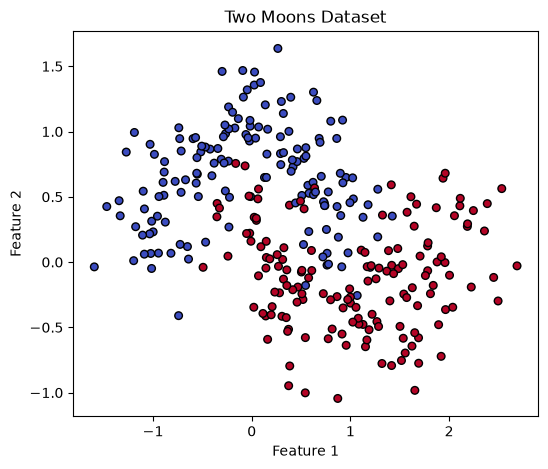

In [58]:
def generate_moons_dataset(n_samples: int=300, noise: float=0.25, seed: int=42):
    "Generates the Two Moons dataset."
    try:
        from sklearn.datasets import make_moons #just for makeing dataset not creating model
        X , y=make_moons(n_samples=n_samples, noise=noise, random_state=seed)
        return X,y
    except ImportError:
        rng = np.random.default_rng(seed)
        n = n_samples//2 
        theta1 = np.linspace(0, np.pi, n)
        theta2 = np.linsapce(0, np.pi, n)
        x1 = np.column_stack([np.cos(theta1) , np.sin(theta1)])
        x2 = np.column_stack([ 1 - np.cos(theta2) , 1 - np.sin(theta2) - 0.5])
        X = np.vstack([x1, x2])
        X += rng.normal(scale=noise, size=X.shape)
        y = np.array([0] * n + [1] * n)
        return X,y

X, y = generate_moons_dataset(n_samples=300, noise=0.25, seed=42)

plt.figure(figsize=(6,5))
plt.scatter(X[:,0],X[:,1], c=y, cmap="coolwarm", edgecolors="k", s=30)
plt.title("Two Moons Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


## 5. Train/Test Data Splitting (Manual Implementation, without`sklearn.model_selection`)

In [59]:
rng = np.random.default_rng(0)
indices = rng.permutation(len(X))
split = int(0.8 * len(X))
train_idx, test_idx = indices[:split], indices[split:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f"Number of training samples: {len(X_train)}")
print(f"Number of test samples: {len(X_test)}")

Number of training samples: 240
Number of test samples: 60


## 6. Model Training

In [60]:
tree = DecisionTreeFromScratch(max_depth=5, min_samples_split=4, criterion="gini")

tree.fit(X_train, y_train)

train_acc = tree.score(X_train, y_train)

test_acc = tree.score(X_test, y_test)

print(f"Training accuracy: {train_acc:.4f}")

print(f"Test accuracy: {test_acc:.4f}")

Training accuracy: 0.9625
Test accuracy: 0.9000


## 7. Display the Structure of the Trained Decision Tree 

In [61]:
tree.print_tree(feature_names=["x1", "x2"])

If x2 <= 0.449 (n=240, gini=0.499):
  If x1 <= -0.640 (n=148, gini=0.354):
    Leaf -> Class 0 (n=15, gini=0.000)
  Otherwise:
    If x2 <= -0.046 (n=133, gini=0.245):
      If x2 <= -0.265 (n=71, gini=0.028):
        Leaf -> Class 1 (n=45, gini=0.000)
      Otherwise:
        If x2 <= -0.256 (n=26, gini=0.074):
          Leaf -> Class 0 (n=1, gini=0.000)
        Otherwise:
          Leaf -> Class 1 (n=25, gini=0.000)
    Otherwise:
      If x1 <= 1.277 (n=62, gini=0.412):
        If x1 <= 0.530 (n=42, gini=0.490):
          Leaf -> Class 1 (n=22, gini=0.165)
        Otherwise:
          Leaf -> Class 0 (n=20, gini=0.320)
      Otherwise:
        Leaf -> Class 1 (n=20, gini=0.000)
Otherwise:
  If x1 <= 1.277 (n=92, gini=0.194):
    If x2 <= 0.568 (n=87, gini=0.108):
      If x2 <= 0.558 (n=21, gini=0.363):
        If x1 <= 0.494 (n=19, gini=0.266):
          Leaf -> Class 0 (n=11, gini=0.397)
        Otherwise:
          Leaf -> Class 0 (n=8, gini=0.000)
      Otherwise:
        Leaf -

## 8.Decision Boundary

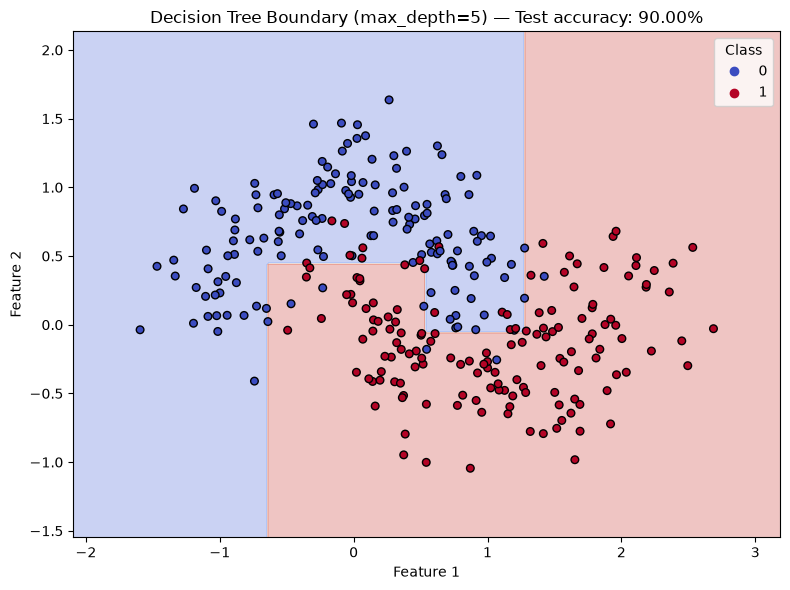

In [62]:
def plot_decision_boundary(model, X, y, title):
    """Plots the model's decision boundary on a two-dimensional dataset."""
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid_points).reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolors="k", s=30)
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend(*scatter.legend_elements(), title="Class")
    plt.tight_layout()
    plt.show()


plot_decision_boundary(
    tree, X, y,
    title=f"Decision Tree Boundary (max_depth=5) — Test accuracy: {test_acc:.2%}",
)

## ## 9. Bonus: The Effect of `max_depth` on Overfitting

To better understand the role of the `max_depth` hyperparameter in preventing overfitting, we train the model with different tree depths.

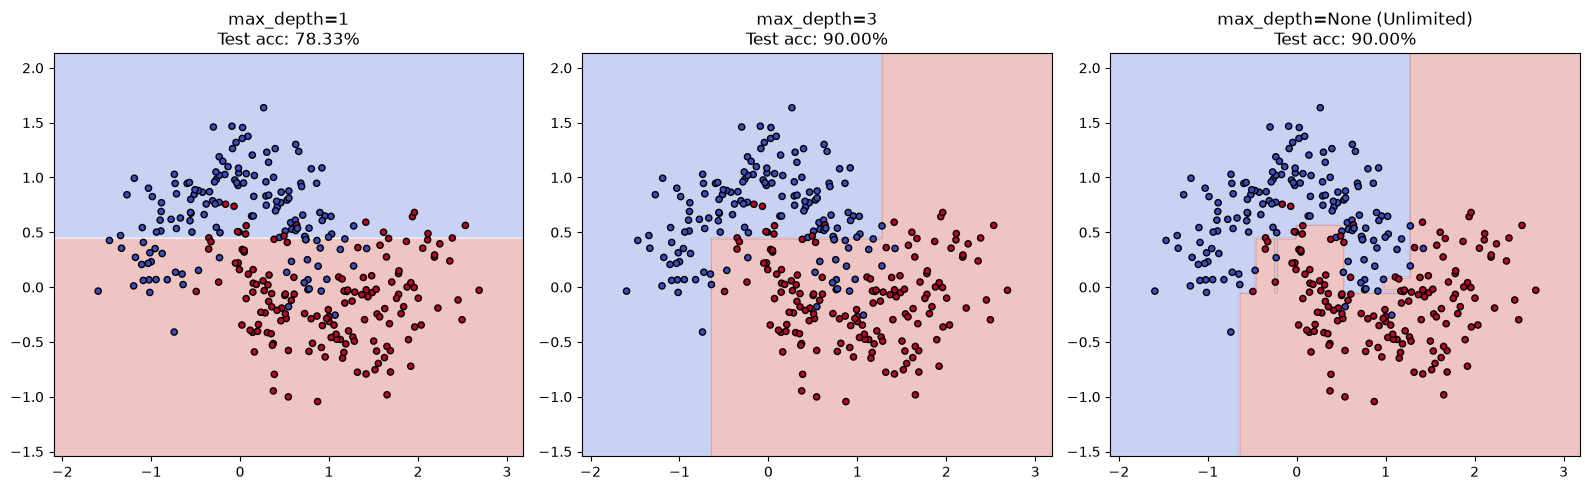

In [63]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5)) 
 
for ax, depth in zip(axes, [1, 3, None]): 
    t = DecisionTreeFromScratch(max_depth=depth, min_samples_split=4) 
    t.fit(X_train, y_train) 
    acc = t.score(X_test, y_test) 
 
    h = 0.02 
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5 
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5 
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    ) 
    Z = t.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape) 
 
    ax.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm") 
    ax.scatter(
        X[:, 0], X[:, 1],
        c=y,
        cmap="coolwarm",
        edgecolors="k",
        s=20
    ) 
    depth_label = depth if depth is not None else "None (Unlimited)" 
    ax.set_title(f"max_depth={depth_label}\nTest acc: {acc:.2%}") 
 
plt.tight_layout() 
plt.show()